# 11: Multi-Race Clustering

`04` restricted clustering to Mayor, Vice Mayor, and Councilor because those are the only three
positions actually decided by the locality voting on them. Every other position on the ballot
(Governor, House, Senator, President, Party List, ...) is still reported per locality in
`locality_features.parquet` (81 columns, one set of top1_share/margin/hhi/enc per position) --
it was just never clustered.

This notebook runs `04`'s exact method (log-transform ENC, standardize, PCA to 90% variance,
k-means sweep k=2..10 picked by silhouette) against five more position groups, so the app can
show a landslide/competitive-equivalent split for whichever race a viewer picks, not only the
local one. It reuses `04`'s feature-matrix logic through `build_group_feature_matrix` in
`common.py` (`build_core_feature_matrix` is now a thin wrapper around it, added in this notebook,
kept because `01`-`08` already import it by that name) rather than duplicating it five times.

In [1]:
import sys
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

sys.path.insert(0, str(Path("..") / "src"))
from common import build_group_feature_matrix, CORE_METRICS
from geo import join_province_clusters, KNOWN_UNMAPPABLE_PROVINCES

pd.set_option("display.max_columns", 40)
print("pandas:", pd.__version__, "| geopandas:", gpd.__version__)

pandas: 3.0.2 | geopandas: 1.1.4


In [2]:
CONFIG = {
    "raw_dir": "../data/raw",
    "processed_dir": "../data/processed",
    "pca_variance_target": 0.90,
    "k_range": range(2, 11),
    "random_state": 42,
}

raw_dir = Path(CONFIG["raw_dir"])
processed_dir = Path(CONFIG["processed_dir"])
print("Config set.")

Config set.


## Position groups

Five groups, chosen by who the race is actually reported against, not by lumping everything
national together:

- **Provincial** -- Governor, Vice Governor, Provincial Board Member. Same candidate slate
  reported across every city in a province (confirmed in `03`), but each city's own vote split
  for that slate is still real, locality-level data.
- **Congressional** -- House of Representatives alone, one position, shared across a district.
- **Presidential** -- President and Vice President together, both single-winner national races.
- **Senate** -- kept separate from President/VP on purpose. The Senate elects 12 winners at
  once from a field that regularly runs into the dozens of candidates, so `top1_share` and `enc`
  do not mean the same thing here as for a single-winner race -- a "landslide" cluster for Senate
  is really a *less fragmented* vote, not one candidate dominating the way a Mayor or President
  race can. Reported with that caveat attached, not silently blended into "national."
- **Party List** -- its own proportional-representation system, same caveat as Senate to a
  lesser degree, kept as its own group rather than folded into anything else.

`PRESIDENT`/`VICE PRESIDENT` are only on the ballot in 2010, 2016, and 2022 (established in
`01`/`data/README.md`); `GOVERNOR`/`VICE GOVERNOR`/`PROVINCIAL BOARD MEMBER`/`SENATOR`/`MEMBER,
HOUSE OF REPRESENTATIVES`/`PARTYLIST` all have zero rows in 2013 (established in `04`). Both
are real gaps in the source reporting, not something this notebook works around -- each group's
own complete-case count is reported below rather than assumed.

In [3]:
locality_features = pd.read_parquet(processed_dir / "locality_features.parquet")

GROUPS = {
    "provincial":    {"positions": ["GOVERNOR", "VICE GOVERNOR", "PROVINCIAL BOARD MEMBER"],
                       "headline": "GOVERNOR", "label": "Provincial"},
    "congressional": {"positions": ["MEMBER, HOUSE OF REPRESENTATIVES"],
                       "headline": "MEMBER, HOUSE OF REPRESENTATIVES", "label": "Congressional (House)"},
    "presidential":  {"positions": ["PRESIDENT", "VICE PRESIDENT"],
                       "headline": "PRESIDENT", "label": "Presidential"},
    "senate":        {"positions": ["SENATOR"], "headline": "SENATOR", "label": "Senate"},
    "partylist":     {"positions": ["PARTYLIST"], "headline": "PARTYLIST", "label": "Party List"},
}
print(f"{len(locality_features):,} locality-years available across all positions.")

9,570 locality-years available across all positions.


## Clustering, one group at a time

Same pipeline as `04` for each group: complete-case filter on that group's own features, log the
ENC columns, standardize, PCA to 90% cumulative variance, sweep k=2..10, pick by silhouette,
fit final k-means. After fitting, the cluster carrying the higher headline-position `top1_share`
is relabeled to `0` (KMeans assigns cluster numbers arbitrarily) so it always means "the more
lopsided cluster," matching `04`'s output and letting `geo.py`'s `province_cluster_summary`
(which assumes cluster `0` is the dominant one) run unmodified for every group.

In [4]:
pca_coords_2d = {}


def run_group(locality_features, positions, headline, label, gid):
    df, X, feature_cols = build_group_feature_matrix(locality_features, positions, CORE_METRICS)
    n_total = len(locality_features)
    n_complete = len(df)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    pca_full = PCA(random_state=CONFIG["random_state"]).fit(X_scaled)
    cum_var = np.cumsum(pca_full.explained_variance_ratio_)
    n_components = max(2, int(np.searchsorted(cum_var, CONFIG["pca_variance_target"]) + 1))
    n_components = min(n_components, X_scaled.shape[1])
    pca = PCA(n_components=n_components, random_state=CONFIG["random_state"])
    X_pca = pca.fit_transform(X_scaled)

    sil_scores = [silhouette_score(X_pca, KMeans(n_clusters=k, random_state=CONFIG["random_state"],
                                                  n_init=10).fit_predict(X_pca))
                  for k in CONFIG["k_range"]]
    best_k = list(CONFIG["k_range"])[int(np.argmax(sil_scores))]

    kmeans = KMeans(n_clusters=best_k, random_state=CONFIG["random_state"], n_init=10)
    df["cluster"] = kmeans.fit_predict(X_pca)
    final_sil = silhouette_score(X_pca, df["cluster"])

    headline_share_col = f"{headline}_top1_share"
    dominant_cluster = df.groupby("cluster")[headline_share_col].mean().idxmax()
    if dominant_cluster != 0:
        df["cluster"] = df["cluster"].map(lambda c: 0 if c == dominant_cluster else (dominant_cluster if c == 0 else c))

    sizes = (df["cluster"].value_counts(normalize=True).sort_index() * 100).round(1)
    profile = df.groupby("cluster")[feature_cols].mean().round(3)

    df[["year", "province", "city", "region", "cluster"] + feature_cols].to_parquet(
        processed_dir / f"locality_clusters_{gid}.parquet", index=False)

    print(f"-- {label} ({'+'.join(positions)}) --")
    print(f"complete cases: {n_complete:,} / {n_total:,} ({n_complete/n_total:.1%})")
    print(f"PCA: {n_components} components for {cum_var[n_components-1]:.1%} variance")
    print(f"best k={best_k}, silhouette={final_sil:.3f}")
    print(f"dominant-cluster share: {sizes.get(0, 0.0):.1f}%")
    print()

    pca_coords_2d[gid] = {"xy": X_pca[:, :2], "cluster": df["cluster"].to_numpy(), "label": label}

    return {"label": label, "n_total": n_total, "n_complete": n_complete, "best_k": best_k,
            "silhouette": round(final_sil, 3), "dominant_share_pct": float(sizes.get(0, 0.0)),
            "n_components": n_components}

summary_rows = {}
for gid, spec in GROUPS.items():
    summary_rows[gid] = run_group(locality_features, spec["positions"], spec["headline"], spec["label"], gid)

-- Provincial (GOVERNOR+VICE GOVERNOR+PROVINCIAL BOARD MEMBER) --
complete cases: 7,405 / 9,570 (77.4%)
PCA: 3 components for 93.2% variance
best k=2, silhouette=0.432
dominant-cluster share: 38.3%



-- Congressional (House) (MEMBER, HOUSE OF REPRESENTATIVES) --
complete cases: 7,562 / 9,570 (79.0%)
PCA: 2 components for 99.9% variance
best k=2, silhouette=0.659
dominant-cluster share: 40.1%



-- Presidential (PRESIDENT+VICE PRESIDENT) --
complete cases: 4,790 / 9,570 (50.1%)
PCA: 2 components for 97.7% variance
best k=2, silhouette=0.518
dominant-cluster share: 31.8%



-- Senate (SENATOR) --
complete cases: 8,053 / 9,570 (84.1%)
PCA: 2 components for 97.6% variance
best k=2, silhouette=0.783
dominant-cluster share: 3.8%



-- Party List (PARTYLIST) --
complete cases: 7,587 / 9,570 (79.3%)
PCA: 2 components for 99.8% variance
best k=2, silhouette=0.584
dominant-cluster share: 30.3%



In [5]:
summary = pd.DataFrame(summary_rows).T
summary.index.name = "group"
display(summary[["label", "n_complete", "n_total", "best_k", "silhouette", "dominant_share_pct"]])

,label,n_complete,n_total,best_k,silhouette,dominant_share_pct
group,,,,,,
provincial,Provincial,7405,9570,2,0.432,38.3
congressional,Congressional (House),7562,9570,2,0.659,40.1
presidential,Presidential,4790,9570,2,0.518,31.8
senate,Senate,8053,9570,2,0.783,3.8
partylist,Party List,7587,9570,2,0.584,30.3


### Cluster shape in PCA space, group by group

Same visual check `04` ran for the local model, once per new group: the first two principal components, colored by final cluster assignment. Not meant to show a clean gap between colors -- PCA-space clusters from vote-share features rarely look like textbook blobs -- just that the two clusters occupy visually distinct regions rather than being randomly interleaved, which would suggest the clustering found nothing real.

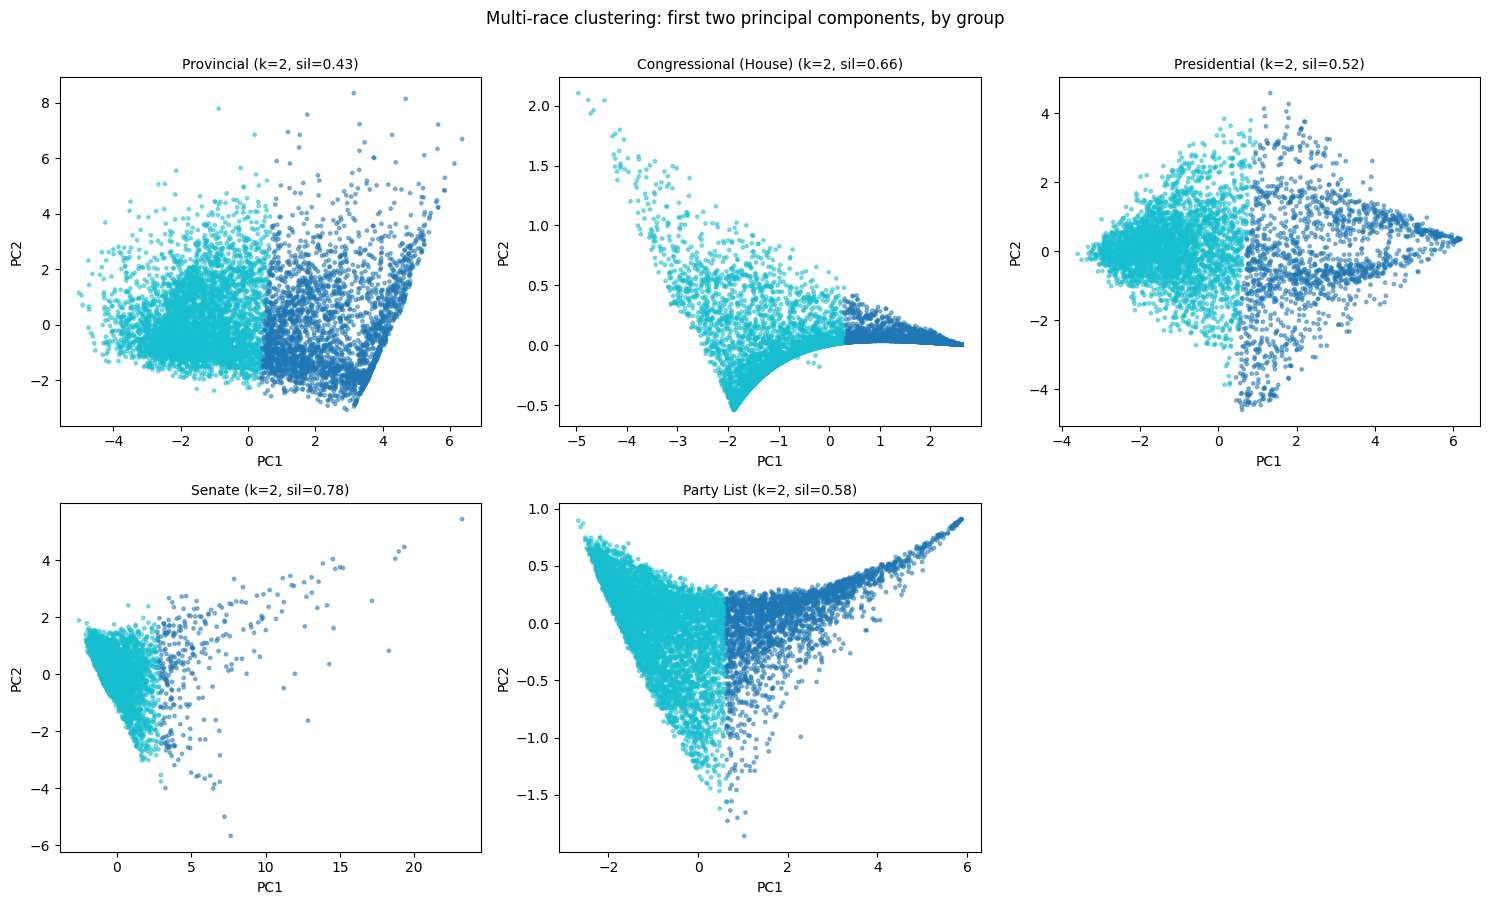

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()
for ax, gid in zip(axes, GROUPS):
    coords = pca_coords_2d[gid]
    xy, cluster, label = coords["xy"], coords["cluster"], coords["label"]
    ax.scatter(xy[:, 0], xy[:, 1], c=cluster, cmap="tab10", s=6, alpha=0.5)
    ax.set_title(f"{label} (k={summary_rows[gid]['best_k']}, sil={summary_rows[gid]['silhouette']:.2f})", fontsize=10)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
axes[-1].axis("off")
fig.suptitle("Multi-race clustering: first two principal components, by group", y=1.00)
fig.tight_layout()
plt.show()

Four of the five groups land on a clean two-cluster split with silhouette scores in the
same range `04` found for the local model (0.43-0.66, against `04`'s 0.534). Senate is the
outlier at 0.783, but with a 96.2%/3.8% split rather than anything near even -- consistent with
the caveat above: almost every locality's Senate vote is heavily fragmented across dozens of
candidates (mean ENC in the high teens to mid-20s in both clusters), so the "dominant" cluster
here means *comparatively* less fragmented, not a landslide winner the way a Mayor or President
race can have one.

## Comparing all six races

Pulling in the local model's own already-saved result (`04`'s `locality_clusters.parquet`, not re-fit here) alongside the five groups above, side by side. This is the view `04` alone could never produce -- it only knew about one race.

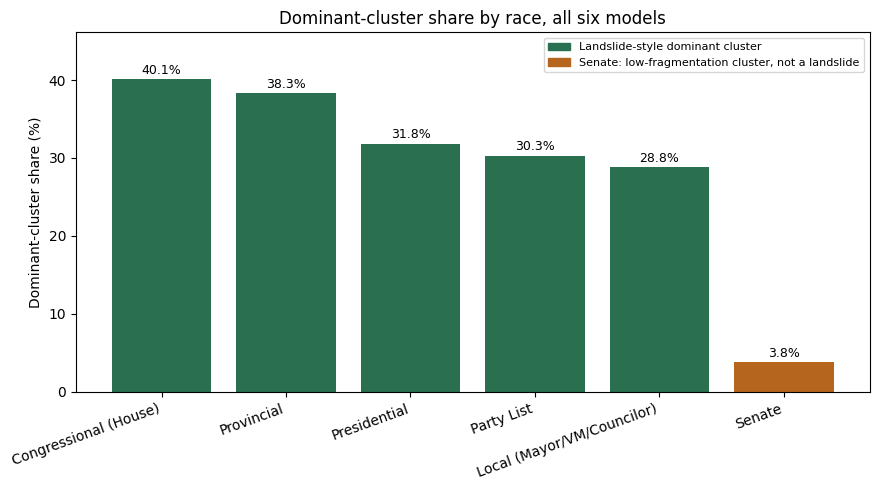

,label,dominant_share_pct
0,Congressional (House),40.1
1,Provincial,38.3
2,Presidential,31.8
3,Party List,30.3
4,Local (Mayor/VM/Councilor),28.8
5,Senate,3.8


In [7]:
local_clusters = pd.read_parquet(processed_dir / "locality_clusters.parquet")
local_dominant_share = float((local_clusters["cluster"] == 0).mean() * 100)

compare_rows = [{"group": "local", "label": "Local (Mayor/VM/Councilor)",
                 "dominant_share_pct": round(local_dominant_share, 1), "is_landslide": True}]
for gid, row in summary_rows.items():
    compare_rows.append({"group": gid, "label": row["label"],
                          "dominant_share_pct": row["dominant_share_pct"],
                          "is_landslide": gid != "senate"})
compare_df = pd.DataFrame(compare_rows).sort_values("dominant_share_pct", ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#2a6f4f" if row.is_landslide else "#b5651d" for row in compare_df.itertuples()]
bars = ax.bar(compare_df["label"], compare_df["dominant_share_pct"], color=colors)
for bar, pct in zip(bars, compare_df["dominant_share_pct"]):
    ax.annotate(f"{pct:.1f}%", (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                textcoords="offset points", xytext=(0, 4), ha="center", fontsize=9)
ax.set_ylabel("Dominant-cluster share (%)")
ax.set_title("Dominant-cluster share by race, all six models")
ax.set_ylim(0, max(compare_df["dominant_share_pct"]) * 1.15)
plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#2a6f4f", label="Landslide-style dominant cluster"),
                    Patch(color="#b5651d", label="Senate: low-fragmentation cluster, not a landslide")],
          fontsize=8, loc="upper right")
fig.tight_layout()
plt.show()

display(compare_df[["label", "dominant_share_pct"]].reset_index(drop=True))

Congressional and Provincial races land closest to the Local model's own dominant-cluster share (40.1% and 38.3% vs. 28.8%) -- all three are single-winner, locally-decided races. Presidential (31.8%) and Party List (30.3%) sit in the same neighborhood despite being decided at a wider scope. Senate's 3.9% is not comparable to the other five on this chart in the way its bar height suggests -- it is measuring the opposite end of a different phenomenon (fragmentation, not landslide dominance), which is why it is colored and called out separately rather than plotted as if it meant the same thing as the other bars.

## Geographic join

Same join as `09`, run once per group against the already-normalized province boundaries, so a
province name that resolves for the local model resolves identically here -- no group gets its
own separate name-matching logic.

In [8]:
provinces_raw = gpd.read_file(raw_dir / "ph_provinces_raw.geojson")

province_stats_by_race = {}
for gid in GROUPS:
    clusters = pd.read_parquet(processed_dir / f"locality_clusters_{gid}.parquet")
    mapped, province_summary = join_province_clusters(provinces_raw, clusters)
    unmapped = set(province_summary["province"]) - set(mapped["province"])
    assert unmapped.issubset(set(KNOWN_UNMAPPABLE_PROVINCES)), f"{gid}: unexpected unmapped {unmapped}"
    assert mapped["landslide_share"].between(0, 1).all()

    province_summary.to_parquet(processed_dir / f"province_cluster_summary_{gid}.parquet", index=False)
    province_stats_by_race[gid] = {
        row["province"]: {"n": int(row["n_locality_years"]), "l": round(float(row["landslide_share"]), 4)}
        for _, row in mapped.iterrows()
    }
    print(f"{gid:15s} {len(mapped)} of {len(province_summary)} provinces joined "
          f"(unmapped: {sorted(unmapped) or 'none'})")

provincial      83 of 83 provinces joined (unmapped: none)
congressional   87 of 87 provinces joined (unmapped: none)
presidential    85 of 85 provinces joined (unmapped: none)
senate          87 of 88 provinces joined (unmapped: ['SPECIAL GEOGRAPHIC AREA'])
partylist       87 of 88 provinces joined (unmapped: ['SPECIAL GEOGRAPHIC AREA'])


## App export

Two files, alongside the existing `province_clusters.json` (geometry + the local model's stats,
unchanged) and `localities.json` (the local model's per-city history, unchanged, still the only
group with `05`/`06`/`08`'s anomaly-detection and stability numbers attached -- those models were
not re-run for the other five groups in this pass, so their city drill-down shows the cluster
label and underlying numbers only, not an anomaly callout or a stability sentence). Both new files
are additive: nothing already shipped in `app/data/` was changed by this notebook.

- `province_stats_by_race.json` -- `{group: {province: {n, l}}}`, no geometry, so switching the
  map's race selector re-styles the same polygons instead of re-fetching them.
- `locality_races.json` -- `{group: {province: [{c, r, y: {year: {k, s, m, e}}}]}}`, one entry
  per city per group, `s`/`m`/`e` computed from that group's headline position (Governor for
  Provincial, President for Presidential, and so on).

In [9]:
app_data_dir = Path("../app/data")

with open(app_data_dir / "province_stats_by_race.json", "w") as f:
    import json
    json.dump(province_stats_by_race, f)

locality_races = {}
for gid, spec in GROUPS.items():
    df = pd.read_parquet(processed_dir / f"locality_clusters_{gid}.parquet")
    headline = spec["headline"]
    share_col, margin_col, enc_col = f"{headline}_top1_share", f"{headline}_margin", f"{headline}_enc"

    by_province = {}
    for province, pgroup in df.groupby("province"):
        cities = []
        for city, cgroup in pgroup.groupby("city"):
            years = {
                str(int(row["year"])): {
                    "k": int(row["cluster"]),
                    "s": round(float(row[share_col]), 4),
                    "m": round(float(row[margin_col]), 4),
                    "e": round(float(row[enc_col]), 1),
                }
                for _, row in cgroup.iterrows()
            }
            cities.append({"c": city, "r": cgroup["region"].iloc[0], "y": years})
        by_province[province] = cities
    locality_races[gid] = by_province

import json
with open(app_data_dir / "locality_races.json", "w") as f:
    json.dump(locality_races, f, separators=(",", ":"))

province_kb = (app_data_dir / "province_stats_by_race.json").stat().st_size / 1024
locality_kb = (app_data_dir / "locality_races.json").stat().st_size / 1024
print(f"Saved province_stats_by_race.json: {province_kb:.0f} KB")
print(f"Saved locality_races.json: {locality_kb:.0f} KB")

Saved province_stats_by_race.json: 16 KB
Saved locality_races.json: 1904 KB


## Sanity checks

In [10]:
for gid in GROUPS:
    stats = province_stats_by_race[gid]
    assert all(0 <= v["l"] <= 1 for v in stats.values()), f"{gid}: landslide share out of range"
    assert len(stats) >= 80, f"{gid}: unexpectedly few provinces ({len(stats)})"

for gid in GROUPS:
    n_cities = sum(len(v) for v in locality_races[gid].values())
    assert n_cities > 1000, f"{gid}: unexpectedly few city entries ({n_cities})"

print("All sanity checks passed:", ", ".join(GROUPS.keys()))

All sanity checks passed: provincial, congressional, presidential, senate, partylist


## What this does and does not add

This adds a real landslide/competitive-equivalent split for five more race types, each fit
independently on its own features, using the same validated method `04` already used. It does
not add anomaly detection or temporal stability for these five groups -- `05`, `06`, and `08`
were built specifically around the local model and were not re-run here. A city's drill-down for
a non-local race shows its cluster history and the raw share/margin/ENC numbers behind it, same
as the local model's "how this was determined" table, but no "unusual pattern" callout and no
stability sentence, because those numbers do not exist yet for these groups. Extending `05`/`06`/
`08` to the other five groups is listed as follow-on work, not done in this pass.